In [18]:
from sklearn import svm
import pandas as pd    
import numpy as np

In [7]:
dtrain = pd.read_csv(r"H:\Sem-7\CS5691\Assignment-4\Dataset1\train.csv")
dtest = pd.read_csv(r"H:\Sem-7\CS5691\Assignment-4\Dataset1\test.csv")
dval = pd.read_csv(r"H:\Sem-7\CS5691\Assignment-4\Dataset1\val.csv")

xtrain = dtrain.drop(columns=['label'])
ytrain = dtrain['label']

xtest = dtest.drop(columns=['label'])
ytest = dtest['label']

xval = dval.drop(columns=['label'])
yval = dval['label']


In [8]:
from sklearn import svm

clf = svm.SVC(kernel='linear')
clf.fit(xtrain, ytrain)

SVC(kernel='linear')

In [12]:
ytest_pred = clf.predict(xtest)
ytrain_pred = clf.predict(xtrain)
yval_pred = clf.predict(xval)

In [13]:
from sklearn.metrics import accuracy_score

print("Train Accuracy")
print(accuracy_score(ytrain_pred, ytrain))


print("Test Accuracy")
print(accuracy_score(ytest_pred, ytest))  

print("Validation accuracy")
print(accuracy_score(yval_pred, yval))


Train Accuracy
0.9809523809523809
Test Accuracy
0.9833333333333333
Validation accuracy
0.9958333333333333


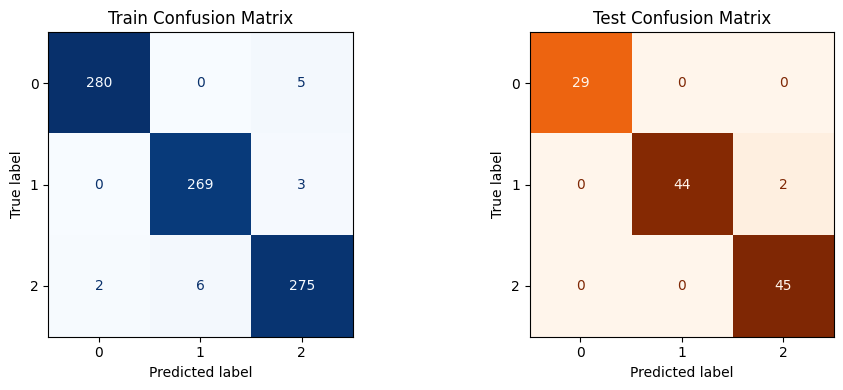

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrices
cm_train = confusion_matrix(ytrain, ytrain_pred)
cm_test = confusion_matrix(ytest, ytest_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_train).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Train Confusion Matrix')

ConfusionMatrixDisplay(cm_test).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Test Confusion Matrix')

plt.tight_layout()
plt.show()


In [ ]:
def plot_decision_regions(clf, X, y, title="Decision Region (Train)"):
    # mesh
    pad = 1.0
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # decision regions
    plt.contourf(xx, yy, Z, alpha=0.3)

    # training points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=35, edgecolors='k')

    # support vectors (works for SVC)
    if hasattr(clf, "support_vectors_"):
        sv = clf.support_vectors_
        plt.scatter(sv[:, 0], sv[:, 1],
                    s=120, facecolors='none', edgecolors='k', linewidths=1.5,
                    label="Support Vectors")
        plt.legend()

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


c:\Users\hrush\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


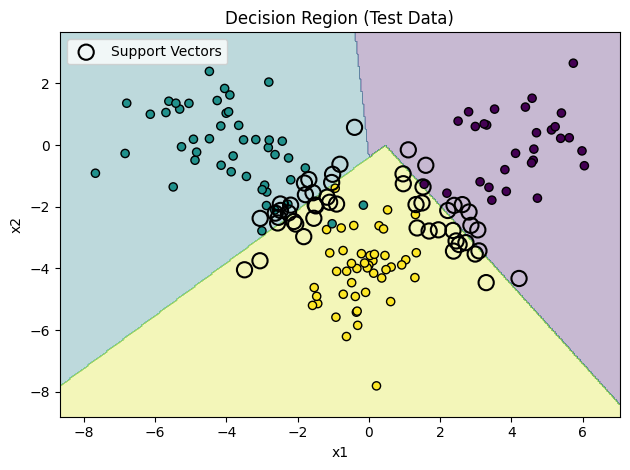

In [20]:
plot_decision_regions(clf, xtest.to_numpy(), ytest.to_numpy().ravel(), title="Decision Region (Test Data)")
